# Thesis

## 1. Data Exploration

### 1.1 Library Import

In [ ]:
# Install all necessary libraries
import sys
print(sys.executable)

# Data exploration
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Data Cleaning
import string
import re
import nltk
import wordcloud
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
from collections import Counter
from wordcloud import WordCloud
from nltk.tokenize import word_tokenize

# Model Preparation
import sklearn
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack
from sklearn.preprocessing import OneHotEncoder


# Legacy Models
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, GRU, SimpleRNN
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

# BERT
from sklearn.model_selection import StratifiedKFold, train_test_split
from transformers import BertTokenizer, BertForSequenceClassification
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification
import torch
from torch.utils.data import DataLoader, RandomSampler, SequentialSampler, TensorDataset
import tensorflow as tf
print(tf.__version__)
from transformers import BertModel, AdamW, get_linear_schedule_with_warmup
from tqdm import tqdm
from joblib import dump
from sklearn.preprocessing import LabelEncoder
import torch.nn as nn
import torch.optim as optim
from torch.utils.tensorboard import SummaryWriter
from torch.utils.data import DataLoader
from collections import deque

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


import warnings
warnings.filterwarnings("ignore")

/usr/bin/python3
2.13.0


/usr/local/lib/python3.10/dist-packages/transformers/utils/generic.py:311: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  torch.utils._pytree._register_pytree_node(
/usr/local/lib/python3.10/dist-packages/transformers/utils/generic.py:311: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  torch.utils._pytree._register_pytree_node(


### 1.2. Data Import

In [ ]:
# Data Import
laptop = pd.read_csv('/content/Laptop_Train_v2.csv', index_col='id')
restaurants = pd.read_csv('/content/Restaurants_Train_v2.csv', index_col='id')

restaurants.head()



,Sentence,Aspect Term,polarity,from,to
id,,,,,
3121,But the staff was so horrible to us.,staff,negative,8,13
2777,"To be completely fair, the only redeeming fact...",food,positive,57,61
1634,"The food is uniformly exceptional, with a very...",food,positive,4,8
1634,"The food is uniformly exceptional, with a very...",kitchen,positive,55,62
1634,"The food is uniformly exceptional, with a very...",menu,neutral,141,145


In [ ]:
# Concatonate the two datasets

data = pd.concat([laptop, restaurants])
data.head()

,Sentence,Aspect Term,polarity,from,to
id,,,,,
2339,I charge it at night and skip taking the cord ...,cord,neutral,41,45
2339,I charge it at night and skip taking the cord ...,battery life,positive,74,86
1316,The tech guy then said the service center does...,service center,negative,27,41
1316,The tech guy then said the service center does...,"""sales"" team",negative,109,121
1316,The tech guy then said the service center does...,tech guy,neutral,4,12


### 1.3. Data Exploration

In [ ]:
# Inspecting the data
print(data.shape)


(6051, 5)


Let us now try and visualise the data for potential anomalies, null values and other such issues. We will also try to understand the distribution of the data.

In [ ]:
# Checking for missing values
data.isnull().sum()



,0
Sentence,0
Aspect Term,0
polarity,0
from,0
to,0


As we can see, there are no missing values in the data, let us now plot this in order to grasp its distribution.

Let us now understand how the target is distributed in the data.

polarity
positive    3151
negative    1671
neutral     1093
conflict     136
Name: count, dtype: int64


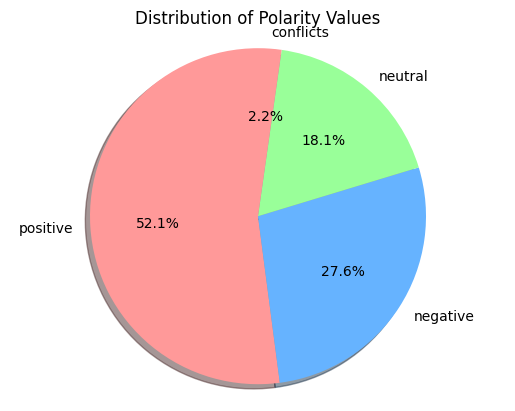

In [ ]:
# Distribution of target values
target_counts = data.polarity.value_counts()
print(target_counts)

# Create a figure with a single subplot
fig, ax = plt.subplots()

# Colors and explode settings for better visualization
colors = ['#ff9999','#66b3ff', '#99ff99']

# Pie chart for target values
ax.pie(target_counts, labels=['positive', 'negative', 'neutral','conflicts'], colors=colors, autopct='%1.1f%%', startangle=90, shadow=True)
ax.set_title('Distribution of Polarity Values')
ax.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.

# Display the plot
plt.show()

In [ ]:
# Drop "Conflict" Entries
data = data[data['polarity'] != 'conflict']

Now we will try to understand which kind of aspects are present in the data. All reviews are filtered by some specific identifying keyword, e.g. "computer" or "battery". Let us now try to understand the distribution of these aspects in the data.

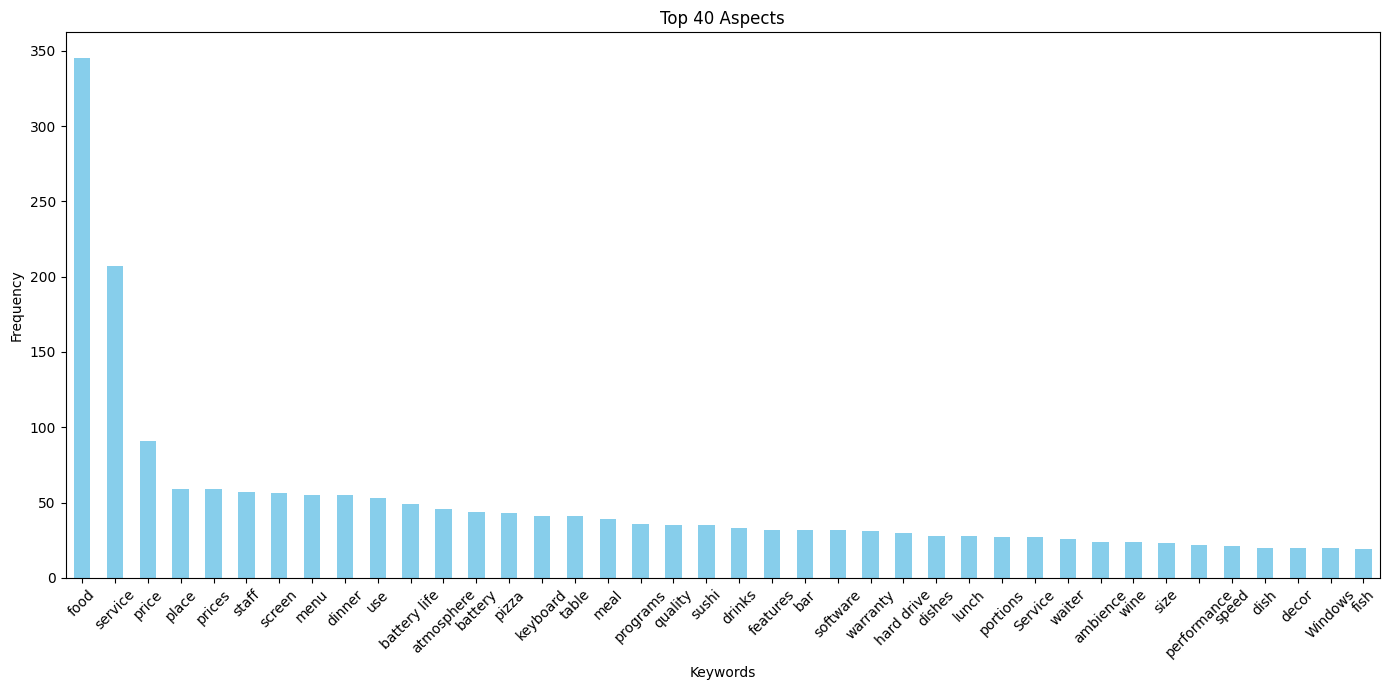

In [ ]:
# Create a bar plot of the top 20 keywords
data['Aspect Term'].value_counts().head(40).plot(kind='bar', figsize=(14, 7), color='skyblue')
plt.title('Top 40 Aspects')
plt.xlabel('Keywords')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Now let us move on to the text itself

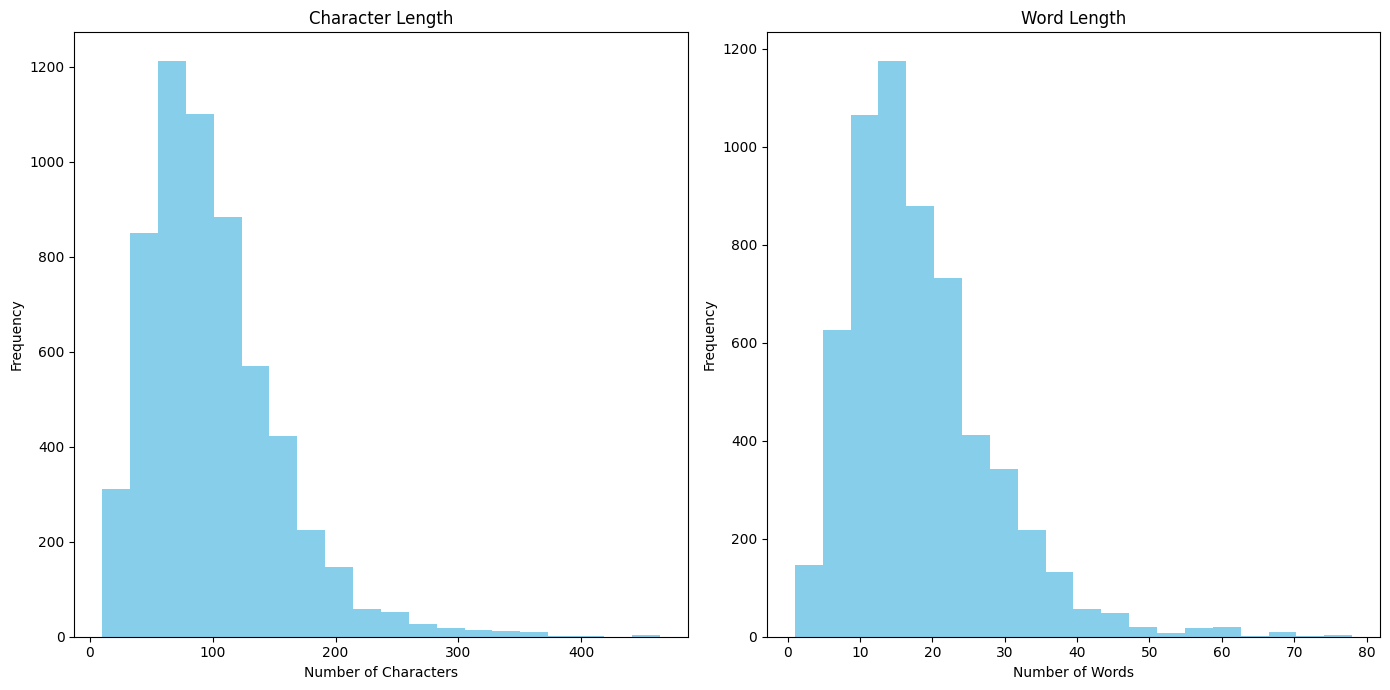

In [ ]:
# Make two bar plots of the character and the word length of the tweets
# Create a figure with two subplots
fig, ax = plt.subplots(1, 2, figsize=(14, 7))

# Character length plot
data['Sentence'].str.len().plot(kind='hist', bins=20, color='skyblue', ax=ax[0])
ax[0].set_title('Character Length')
ax[0].set_xlabel('Number of Characters')
ax[0].set_ylabel('Frequency')

# Word length plot
data['Sentence'].str.split().map(lambda x: len(x)).plot(kind='hist', bins=20, color='skyblue', ax=ax[1])
ax[1].set_title('Word Length')
ax[1].set_xlabel('Number of Words')
ax[1].set_ylabel('Frequency')

# Adjust layout to prevent overlap
plt.tight_layout()

# Display the plots
plt.show()

Now it is helpful to understand whether these numbers differ between the two classes.

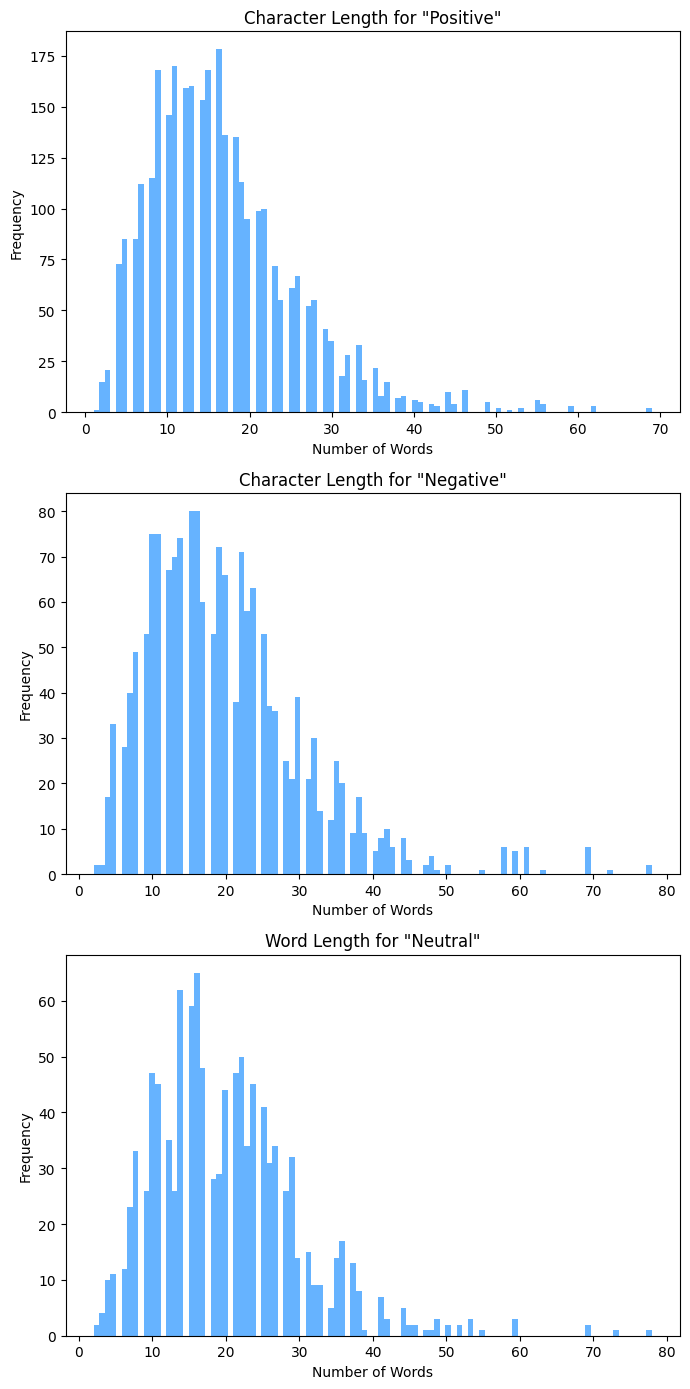

In [ ]:
fig, ax = plt.subplots(3, 1, figsize=(7, 14))

# Character length plot for disaster tweets
word_lengths_positive = data[data['polarity'] == "positive"]['Sentence'].str.split().map(len)
word_lengths_positive.plot(kind='hist', bins=100, color='#66b3ff', ax=ax[0])
ax[0].set_title('Character Length for "Positive"')
ax[0].set_xlabel('Number of Words')
ax[0].set_ylabel('Frequency')

# Character length plot for non-disaster tweets
word_lengths_negative = data[data['polarity'] == 'negative']['Sentence'].str.split().map(len)
word_lengths_negative.plot(kind='hist', bins=100, color='#66b3ff', ax=ax[1])
ax[1].set_title('Character Length for "Negative"')
ax[1].set_xlabel('Number of Words')
ax[1].set_ylabel('Frequency')

# Word length plot for disaster tweets
word_lengths_neutral = data[data['polarity'] == 'neutral']['Sentence'].str.split().map(len)
word_lengths_neutral.plot(kind='hist', bins=100, color='#66b3ff', ax=ax[2])
ax[2].set_title('Word Length for "Neutral"')
ax[2].set_xlabel('Number of Words')
ax[2].set_ylabel('Frequency')


# Adjust layout to prevent overlap
plt.tight_layout()

# Display the plots
plt.show()


We see that the distributions do not vary significantly between the classes. All are quite evenly distributed. The exception is "Conflict" Terms of which there are not many in the data.

### 1.4 Data Cleaning

Let us first fill all empty values:

Since these are reviews, they contain a lot of noise. We will now clean the data by removing all special characters, numbers and other such noise.

Lets begin by removing punctuation and special characters.

In [ ]:
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [ ]:
# Creating a function to remove punctuation
def remove_punctuation(text):
    return text.translate(str.maketrans('', '', string.punctuation))

# Apply the function to the text column
data['clean_sentence'] = data['Sentence'].apply(remove_punctuation)

Moving on to removing URLs

In [ ]:
# Removing URLs
def remove_URL(text):
    url = re.compile(r'https?://\S+|www\.\S+')
    return url.sub(r'',text)

data["clean_sentence"] = data["clean_sentence"].apply(remove_URL)

In [ ]:
# Removing HTML tags
def remove_html(text):
    clean = re.compile('<.*?>')
    # Use sub() to replace HTML tags with an empty string
    return re.sub(clean, '', text)

data["clean_sentence"] = data["clean_sentence"].apply(remove_html)

In [ ]:
data["clean_sentence"] = data["clean_sentence"].str.lower()

Let us further analyse the data by removing stopwords. Before we do this, let us understand how stopwords are distributed in the data.

In [ ]:
# Removing stopwords
nltk.download('stopwords')
stop = set(stopwords.words('english'))

def remove_stopwords(text):
    text = [word for word in text.split() if word.lower() not in stop]
    return " ".join(text)

data["clean_sentence"] = data["clean_sentence"].apply(remove_stopwords)


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
# Stemming
stemmer = PorterStemmer()
def stemming(text):
    text = [stemmer.stem(word) for word in text.split()]
    return " ".join(text)

data["clean_sentence"] = data["clean_sentence"].apply(stemming)

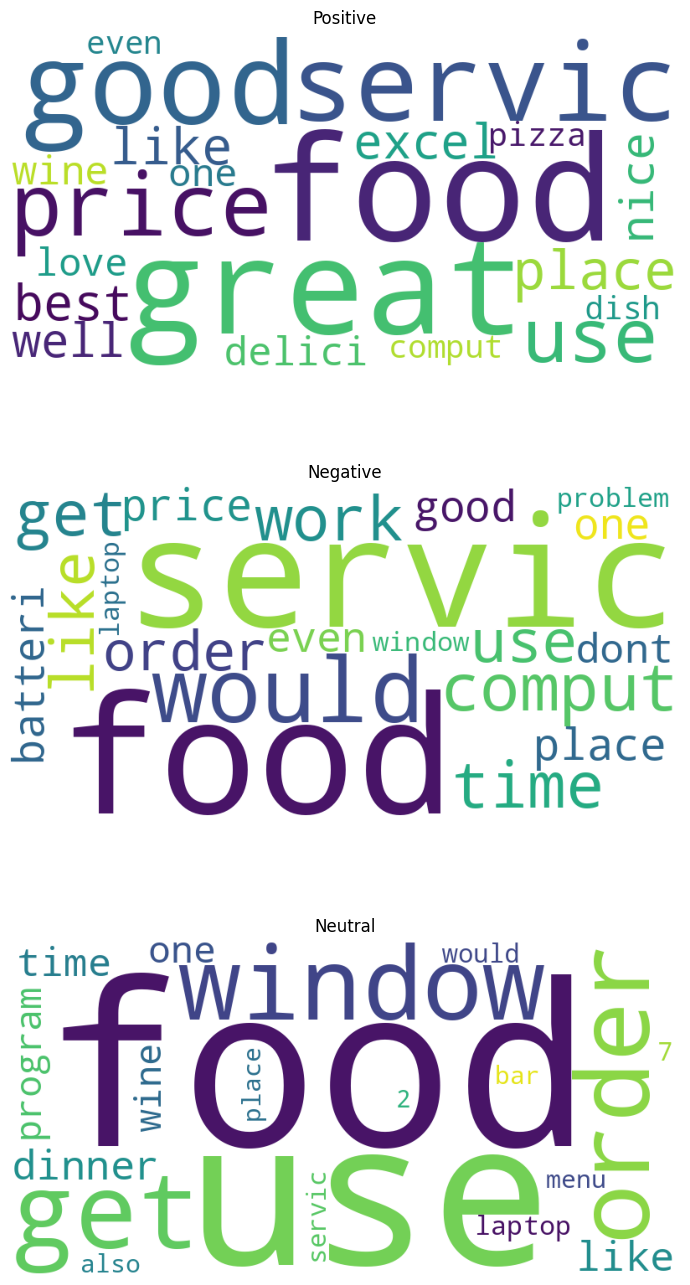

In [ ]:

fig, ax = plt.subplots(3, 1, figsize=(7, 14))

# Get the most common words in positive sentences
positive_words = data[data['polarity'] == "positive"]['clean_sentence'].str.split().explode()
positive_common_words = Counter(positive_words).most_common(20)

# Get the most common words in negative sentences
negative_words = data[data['polarity'] == "negative"]['clean_sentence'].str.split().explode()
negative_common_words = Counter(negative_words).most_common(20)

# Get the most common words in neutral sentences
neutral_words = data[data['polarity'] == "neutral"]['clean_sentence'].str.split().explode()
neutral_common_words = Counter(neutral_words).most_common(20)

# Positive word cloud
wordcloud = WordCloud(width=800, height=400, background_color ='white').generate_from_frequencies(dict(positive_common_words))
ax[0].imshow(wordcloud)
ax[0].set_title('Positive')
ax[0].axis('off')

# Negative word cloud
wordcloud = WordCloud(width=800, height=400, background_color ='white').generate_from_frequencies(dict(negative_common_words))
ax[1].imshow(wordcloud)
ax[1].set_title('Negative')
ax[1].axis('off')

# Neutral word cloud
wordcloud = WordCloud(width=800, height=400, background_color ='white').generate_from_frequencies(dict(neutral_common_words))
ax[2].imshow(wordcloud)
ax[2].set_title('Neutral')
ax[2].axis('off')
# Adjust layout to prevent overlap
plt.tight_layout()

# Display the plots
plt.show()


There are still unnecessary words such as like "amp" and "gt" in the data. Let us remove these as well.

In [ ]:
# Removing common words

# Create a list of common words
common_words = ['amp', 'like', 'get', 'one', 'new', 'via', 'would', 'video', 'know', 'us', 'back', 'watch', 'good', '2', 'first', 'last', 'going',   'still',
                'see', 'think', 'made', 'even', 'look', 'many', 'may', 'next',
                'great', 'well', 'take', 'year', 'say', 'want', 'best', 'come', 'big', 'use', 'week', 'ever', 'let', 'show', 'find',"got",'im']

# Function to find common words in the text
def remove_common(text):
    text = [word for word in text.split() if word not in common_words]
    return " ".join(text)

# Apply the function to the text column
data['clean_sentence'] = data['clean_sentence'].apply(remove_common)

In [ ]:
data.head(10)

,Sentence,Aspect Term,polarity,from,to,clean_sentence
id,,,,,,
2339,I charge it at night and skip taking the cord ...,cord,neutral,41,45,charg night skip cord batteri life
2339,I charge it at night and skip taking the cord ...,battery life,positive,74,86,charg night skip cord batteri life
1316,The tech guy then said the service center does...,service center,negative,27,41,tech guy said servic center 1to1 exchang direc...
1316,The tech guy then said the service center does...,"""sales"" team",negative,109,121,tech guy said servic center 1to1 exchang direc...
1316,The tech guy then said the service center does...,tech guy,neutral,4,12,tech guy said servic center 1to1 exchang direc...
2005,"it is of high quality, has a killer GUI, is ex...",quality,positive,14,21,high qualiti killer gui extrem stabl highli ex...
2005,"it is of high quality, has a killer GUI, is ex...",GUI,positive,36,39,high qualiti killer gui extrem stabl highli ex...
2005,"it is of high quality, has a killer GUI, is ex...",applications,positive,118,130,high qualiti killer gui extrem stabl highli ex...
2005,"it is of high quality, has a killer GUI, is ex...",use,positive,143,146,high qualiti killer gui extrem stabl highli ex...


Let us now tokenize the data.

In [ ]:
# Tokenization
nltk.download('punkt')

def tokenization(text):
    text = re.split('\W+', text)
    return text


data['tokenized_text'] = data['clean_sentence'].apply(tokenization)

data.head()

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


,Sentence,Aspect Term,polarity,from,to,clean_sentence,tokenized_text
id,,,,,,,
2339,I charge it at night and skip taking the cord ...,cord,neutral,41,45,charg night skip cord batteri life,"[charg, night, skip, cord, batteri, life]"
2339,I charge it at night and skip taking the cord ...,battery life,positive,74,86,charg night skip cord batteri life,"[charg, night, skip, cord, batteri, life]"
1316,The tech guy then said the service center does...,service center,negative,27,41,tech guy said servic center 1to1 exchang direc...,"[tech, guy, said, servic, center, 1to1, exchan..."
1316,The tech guy then said the service center does...,"""sales"" team",negative,109,121,tech guy said servic center 1to1 exchang direc...,"[tech, guy, said, servic, center, 1to1, exchan..."
1316,The tech guy then said the service center does...,tech guy,neutral,4,12,tech guy said servic center 1to1 exchang direc...,"[tech, guy, said, servic, center, 1to1, exchan..."


In [ ]:
# Value counts for polarity
data['polarity'].value_counts()

,count
polarity,
positive,3151
negative,1671
neutral,1093


## 2. Model Selection and Training

### RNN

In [ ]:

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, Concatenate, Bidirectional, SimpleRNN, GRU
from sklearn.model_selection import train_test_split

def train_model(model_type):
  # Extract the necessary columns
  sentences = data['Sentence'].astype(str).tolist()
  aspects = data['Aspect Term'].astype(str).tolist()
  polarities = data['polarity'].astype(str).tolist()

  # Encode the polarities to numerical labels
  label_encoder = LabelEncoder()
  labels = label_encoder.fit_transform(polarities)
  labels = np.array(labels)

  # Tokenize the sentences and aspect terms
  tokenizer = Tokenizer()
  tokenizer.fit_on_texts(sentences + aspects)
  vocab_size = len(tokenizer.word_index) + 1  # +1 for padding token

  # Convert texts to sequences
  sentence_sequences = tokenizer.texts_to_sequences(sentences)
  aspect_sequences = tokenizer.texts_to_sequences(aspects)

  # Pad the sequences
  max_sentence_len =  max(len(sentence) for sentence in sentence_sequences)
  max_aspect_len = max(len(aspect) for aspect in aspect_sequences)
  sentence_padded = pad_sequences(sentence_sequences, maxlen=max_sentence_len, padding='post')
  aspect_padded = pad_sequences(aspect_sequences, maxlen=max_aspect_len, padding='post')

  # Split the data into training and testing sets
  X_sentence_train, X_sentence_test, X_aspect_train, X_aspect_test, y_train, y_test = train_test_split(
      sentence_padded, aspect_padded, labels, test_size=0.2, random_state=42)

  # Build the RNN model
  # Sentence input
  sentence_input = Input(shape=(max_sentence_len,), name='sentence_input')
  sentence_embedding = Embedding(input_dim=vocab_size, output_dim=100, input_length=max_sentence_len)(sentence_input)
  sentence_lstm = model_type(sentence_embedding)

  # Aspect input
  aspect_input = Input(shape=(max_aspect_len,), name='aspect_input')
  aspect_embedding = Embedding(input_dim=vocab_size, output_dim=100, input_length=max_aspect_len)(aspect_input)
  aspect_lstm = model_type(aspect_embedding)

  # Concatenate sentence and aspect representations
  merged = Concatenate()([sentence_lstm, aspect_lstm])

  # Fully connected layer
  dense1 = Dense(64, activation='relu')(merged)
  output = Dense(3, activation='softmax')(dense1)  # 3 classes: positive, neutral, negative

  # Define the model
  model = Model(inputs=[sentence_input, aspect_input], outputs=output)

  # Compile the model
  model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

  # Print the model summary
  model.summary()

  # Train the model
  model.fit(
      [X_sentence_train, X_aspect_train],
      y_train,
      batch_size=32,
      epochs=10,
      validation_data=([X_sentence_test, X_aspect_test], y_test)
  )

  # Evaluate the model
  loss, accuracy = model.evaluate([X_sentence_test, X_aspect_test], y_test)
  print('Test Loss:', loss)
  print('Test Accuracy:', accuracy)


### Simple RNN

In [ ]:
train_model(SimpleRNN(64))

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ sentence_input            │ (None, 77)             │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ aspect_input (InputLayer) │ (None, 20)             │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ embedding_4 (Embedding)   │ (None, 77, 100)        │        567,700 │ sentence_input[0][0]   │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ embedding_5 (Embedding)   │ (None, 20, 100)        │        567,700 │ aspect_input[0][0]     │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ simple_rnn_2 (SimpleRNN)  │ (None, 64)             │         10,560 │ embedding_4[0][0],     │
│                           │                        │                │ embedding_5[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate_2             │ (None, 128)            │              0 │ simple_rnn_2[0][0],    │
│ (Concatenate)             │                        │                │ simple_rnn_2[1][0]     │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_4 (Dense)           │ (None, 64)             │          8,256 │ concatenate_2[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_5 (Dense)           │ (None, 3)              │            195 │ dense_4[0][0]          │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 1,154,411 (4.40 MB)

 Trainable params: 1,154,411 (4.40 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 9s 36ms/step - accuracy: 0.5358 - loss: 1.0019 - val_accuracy: 0.5545 - val_loss: 0.9583
Epoch 2/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.5932 - loss: 0.9021 - val_accuracy: 0.5613 - val_loss: 0.9567
Epoch 3/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.6858 - loss: 0.7408 - val_accuracy: 0.5850 - val_loss: 0.9150
Epoch 4/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.7741 - loss: 0.5822 - val_accuracy: 0.5562 - val_loss: 1.1094
Epoch 5/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.7987 - loss: 0.5144 - val_accuracy: 0.5452 - val_loss: 1.0727
Epoch 6/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.8320 - loss: 0.4499 - val_accuracy: 0.5968 - val_loss: 1.1157
Epoch 7/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.8698 - loss: 0.3525 - val_accuracy: 0.5680 - val_loss: 1.2158
Epoch 8/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.8799 - loss: 0.3059 - val_accu

### LSTM

In [ ]:
train_model(LSTM(64))

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ sentence_input            │ (None, 77)             │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ aspect_input (InputLayer) │ (None, 20)             │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ embedding_6 (Embedding)   │ (None, 77, 100)        │        567,700 │ sentence_input[0][0]   │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ embedding_7 (Embedding)   │ (None, 20, 100)        │        567,700 │ aspect_input[0][0]     │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ lstm_1 (LSTM)             │ (None, 64)             │         42,240 │ embedding_6[0][0],     │
│                           │                        │                │ embedding_7[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate_3             │ (None, 128)            │              0 │ lstm_1[0][0],          │
│ (Concatenate)             │                        │                │ lstm_1[1][0]           │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_6 (Dense)           │ (None, 64)             │          8,256 │ concatenate_3[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_7 (Dense)           │ (None, 3)              │            195 │ dense_6[0][0]          │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 1,186,091 (4.52 MB)

 Trainable params: 1,186,091 (4.52 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.5388 - loss: 1.0079 - val_accuracy: 0.5334 - val_loss: 1.0083
Epoch 2/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5303 - loss: 1.0040 - val_accuracy: 0.5334 - val_loss: 1.0064
Epoch 3/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5447 - loss: 0.9833 - val_accuracy: 0.5427 - val_loss: 0.9583
Epoch 4/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6059 - loss: 0.8867 - val_accuracy: 0.5621 - val_loss: 0.9888
Epoch 5/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6356 - loss: 0.8411 - val_accuracy: 0.5613 - val_loss: 0.9528
Epoch 6/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6481 - loss: 0.8106 - val_accuracy: 0.5689 - val_loss: 0.9499
Epoch 7/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6503 - loss: 0.8093 - val_accuracy: 0.5587 - val_loss: 1.0465
Epoch 8/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6591 - loss: 0.7940 - val_accuracy: 0

### Bidirectional LSTM

In [ ]:
train_model(Bidirectional(LSTM(64)))

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ sentence_input            │ (None, 77)             │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ aspect_input (InputLayer) │ (None, 20)             │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ embedding_2 (Embedding)   │ (None, 77, 100)        │        567,700 │ sentence_input[0][0]   │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ embedding_3 (Embedding)   │ (None, 20, 100)        │        567,700 │ aspect_input[0][0]     │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ bidirectional             │ (None, 128)            │         84,480 │ embedding_2[0][0],     │
│ (Bidirectional)           │                        │                │ embedding_3[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate_1             │ (None, 256)            │              0 │ bidirectional[0][0],   │
│ (Concatenate)             │                        │                │ bidirectional[1][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_2 (Dense)           │ (None, 64)             │         16,448 │ concatenate_1[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_3 (Dense)           │ (None, 3)              │            195 │ dense_2[0][0]          │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 1,236,523 (4.72 MB)

 Trainable params: 1,236,523 (4.72 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.5275 - loss: 0.9818 - val_accuracy: 0.6644 - val_loss: 0.7478
Epoch 2/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.7495 - loss: 0.6300 - val_accuracy: 0.7058 - val_loss: 0.7240
Epoch 3/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.8496 - loss: 0.4178 - val_accuracy: 0.7219 - val_loss: 0.7118
Epoch 4/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.8894 - loss: 0.2857 - val_accuracy: 0.7219 - val_loss: 0.7547
Epoch 5/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9302 - loss: 0.1978 - val_accuracy: 0.7126 - val_loss: 0.9056
Epoch 6/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.9493 - loss: 0.1521 - val_accuracy: 0.6915 - val_loss: 1.0905
Epoch 7/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.9600 - loss: 0.1142 - val_accuracy: 0.7058 - val_loss: 1.1453
Epoch 8/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9661 - loss: 0.0918 - val_accu

### Bidirectional GRU

In [ ]:
train_model(Bidirectional(GRU(64)))

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ sentence_input            │ (None, 77)             │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ aspect_input (InputLayer) │ (None, 20)             │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ embedding_8 (Embedding)   │ (None, 77, 100)        │        567,700 │ sentence_input[0][0]   │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ embedding_9 (Embedding)   │ (None, 20, 100)        │        567,700 │ aspect_input[0][0]     │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ bidirectional_1           │ (None, 128)            │         63,744 │ embedding_8[0][0],     │
│ (Bidirectional)           │                        │                │ embedding_9[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate_4             │ (None, 256)            │              0 │ bidirectional_1[0][0], │
│ (Concatenate)             │                        │                │ bidirectional_1[1][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_8 (Dense)           │ (None, 64)             │         16,448 │ concatenate_4[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_9 (Dense)           │ (None, 3)              │            195 │ dense_8[0][0]          │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 1,215,787 (4.64 MB)

 Trainable params: 1,215,787 (4.64 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.5390 - loss: 0.9748 - val_accuracy: 0.6526 - val_loss: 0.7536
Epoch 2/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.7567 - loss: 0.6129 - val_accuracy: 0.7092 - val_loss: 0.7011
Epoch 3/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.8416 - loss: 0.4110 - val_accuracy: 0.7008 - val_loss: 0.7534
Epoch 4/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.8965 - loss: 0.2765 - val_accuracy: 0.6906 - val_loss: 0.8121
Epoch 5/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9277 - loss: 0.2138 - val_accuracy: 0.6915 - val_loss: 0.9475
Epoch 6/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9508 - loss: 0.1413 - val_accuracy: 0.6898 - val_loss: 1.0115
Epoch 7/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9637 - loss: 0.1117 - val_accuracy: 0.6822 - val_loss: 1.0915
Epoch 8/10
148/148 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9644 - loss: 0.1049 - val_accu

### 2.2 Sentiment Analysis using BERT

In [ ]:
import transformers

In [ ]:
print("TensorFlow version:", tf.__version__)  # Should be >= 2.13
print("Transformers version:", transformers.__version__)

TensorFlow version: 2.17.0
Transformers version: 4.44.2


In [ ]:
!pip install transformers==4.33.3
!pip install tensorflow==2.13.0

  Using cached tensorflow-2.13.0-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (3.4 kB)
  Using cached gast-0.4.0-py3-none-any.whl.metadata (1.1 kB)
  Using cached keras-2.13.1-py3-none-any.whl.metadata (2.4 kB)
  Using cached numpy-1.24.3-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (5.6 kB)
  Using cached tensorboard-2.13.0-py3-none-any.whl.metadata (1.8 kB)
  Using cached tensorflow_estimator-2.13.0-py2.py3-none-any.whl.metadata (1.3 kB)
  Using cached typing_extensions-4.5.0-py3-none-any.whl.metadata (8.5 kB)
  Using cached google_auth_oauthlib-1.0.0-py2.py3-none-any.whl.metadata (2.7 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 524.1/524.1 MB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 76.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.3/17.3 MB 93.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 109.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
import pandas as pd
import numpy as np
from transformers import BertTokenizer, TFBertForSequenceClassification
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder


# Extract the necessary columns
sentences = data['Sentence'].astype(str).tolist()
aspects = data['Aspect Term'].astype(str).tolist()
polarities = data['polarity'].astype(str).tolist()

# Encode the polarities to numerical labels
label_encoder = LabelEncoder()
labels = label_encoder.fit_transform(polarities)
labels = np.array(labels)


# Prepare the input sequences
def prepare_input(aspect, sentence):
    # Combine aspect and sentence using the [SEP] token
    return '[CLS] ' + aspect + ' [SEP] ' + sentence + ' [SEP]'

inputs = [prepare_input(a, s) for a, s in zip(aspects, sentences)]

# Split the data into training and testing sets before tokenization
X_train_texts, X_test_texts, y_train, y_test = train_test_split(
    inputs,
    labels,
    test_size=0.2,
    random_state=42
)

# Initialize the tokenizer
model_name = 'bert-base-uncased'  # You can choose other pre-trained models
tokenizer = BertTokenizer.from_pretrained(model_name)

# Tokenize the training data
train_encodings = tokenizer(
    X_train_texts,
    truncation=True,
    padding=True,
    max_length=128,
    return_tensors='tf'
)

# Tokenize the testing data
test_encodings = tokenizer(
    X_test_texts,
    truncation=True,
    padding=True,
    max_length=128,
    return_tensors='tf'
)


num_labels = len(label_encoder.classes_)
model = TFBertForSequenceClassification.from_pretrained(
    model_name,
    num_labels=num_labels
)

# Compile the model
optimizer = tf.keras.optimizers.Adam(learning_rate=2e-5)
loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
metric = tf.keras.metrics.SparseCategoricalAccuracy('accuracy')

model.compile(optimizer=optimizer, loss=loss, metrics=[metric])

# Train the model
history = model.fit(
    {'input_ids': train_encodings['input_ids'], 'attention_mask': train_encodings['attention_mask']},
    y_train,
    validation_data=(
        {'input_ids': test_encodings['input_ids'], 'attention_mask': test_encodings['attention_mask']},
        y_test
    ),
    epochs=3,
    batch_size=16
)

# Evaluate the model
loss, accuracy = model.evaluate(
    {'input_ids': test_encodings['input_ids'], 'attention_mask': test_encodings['attention_mask']},
    y_test
)
print('Test Loss:', loss)
print('Test Accuracy:', accuracy)

All PyTorch model weights were used when initializing TFBertForSequenceClassification.

Some weights or buffers of the TF 2.0 model TFBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1/3
296/296 [==============================] - 598s 2s/step - loss: 0.6956 - accuracy: 0.7172 - val_loss: 0.5867 - val_accuracy: 0.7633
Epoch 2/3
296/296 [==============================] - 565s 2s/step - loss: 0.4874 - accuracy: 0.8145 - val_loss: 0.4798 - val_accuracy: 0.8090
Epoch 3/3
37/37 [==============================] - 38s 1s/step - loss: 0.4792 - accuracy: 0.8225
Test Loss: 0.479236900806427
Test Accuracy: 0.8224852085113525
